In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image


In [2]:
content_path = "/content/tajmahal.jpg"
style_path = "/content/vangogh.jpg"

img_size = 400

def load_img(path):
    img = image.load_img(path, target_size=(img_size, img_size))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return preprocess_input(img)

content_image = load_img(content_path)
style_image = load_img(style_path)


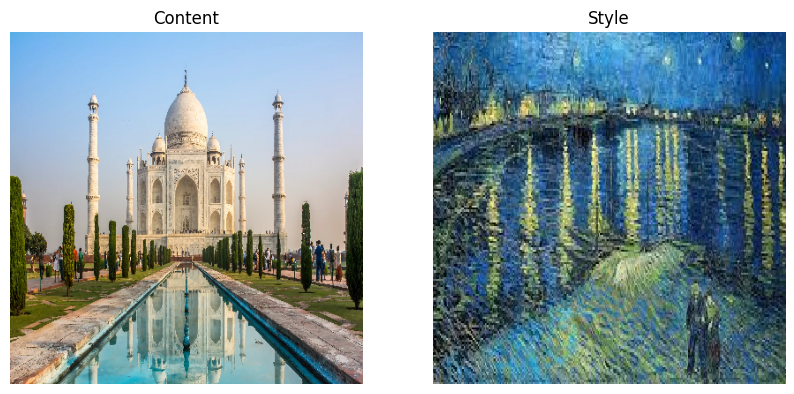

In [3]:
def show_image(img, title="Image"):
    img = img.copy()
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]
    img = np.clip(img, 0, 255).astype('uint8')

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
show_image(content_image[0],"Content")

plt.subplot(1,2,2)
show_image(style_image[0],"Style")
plt.show()


In [4]:
vgg = VGG19(weights='imagenet', include_top=False)

for layer in vgg.layers:
    layer.trainable = False


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
content_layer = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]


In [6]:
outputs = [vgg.get_layer(name).output for name in style_layers + content_layer]

model = tf.keras.Model(vgg.input, outputs)


In [7]:
def content_loss(base, target):
    return tf.reduce_mean(tf.square(base - target))


In [8]:
def gram_matrix(x):
    x = tf.reshape(x, (-1, x.shape[-1]))
    gram = tf.matmul(x, x, transpose_a=True)
    return gram / tf.cast(tf.shape(x)[0], tf.float32)

def style_loss(base, target):
    G = gram_matrix(base)
    A = gram_matrix(target)
    return tf.reduce_mean(tf.square(G - A))


In [9]:
style_features = model(style_image)
content_features = model(content_image)


In [10]:
generated_image = tf.Variable(content_image, dtype=tf.float32)


In [11]:
style_weight = 1e-2
content_weight = 1e4

def compute_loss(gen_img):

    gen_features = model(gen_img)

    style_score = 0
    content_score = 0

    for i in range(len(style_layers)):
        style_score += style_loss(
            gen_features[i],
            style_features[i]
        )

    content_score += content_loss(
        gen_features[-1],
        content_features[-1]
    )

    total_loss = style_weight*style_score + content_weight*content_score

    return total_loss


In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5.0)

epochs = 200

for i in range(epochs):
    with tf.GradientTape() as tape:
        loss = compute_loss(generated_image)

    grads = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grads, generated_image)])

    generated_image.assign(
        tf.clip_by_value(generated_image, -127, 127)
    )

    if i % 50 == 0:
        print(f"Iteration {i}, Loss: {loss.numpy()}")


Iteration 0, Loss: 1212483072.0
Iteration 50, Loss: 23951372.0
Iteration 100, Loss: 15342830.0
Iteration 150, Loss: 12422709.0


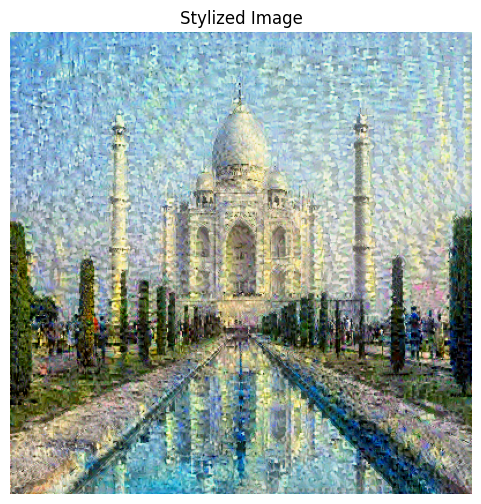

In [13]:
plt.figure(figsize=(6,6))
show_image(generated_image.numpy()[0],
           "Stylized Image")
plt.show()
